In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats

# Define unified corporate visual aesthetics
CORPORATE_PALETTE = ['#1f4e79', '#2e75b6', '#bdd7ee', '#ffc000', '#ed7d31']
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.5
sns.set_palette(CORPORATE_PALETTE)

# Task 1: Customer Segmentation & Behavioral Insights Pipeline
## Data Ingestion, Structural Validation, and Algorithmic Cleaning

### Business Objective
The purpose of this pipeline is to ingest, clean, and analyze fast-moving consumer goods (FMCG) transaction logs and customer profiling datasets. By removing operational anomalies, parsing text parameters, and identifying purchasing trends, this workflow establishes a verified data core for category management strategy.


In [39]:
# Ingest raw retail datasets
df_tra = pd.read_csv('QVI_transaction_data.csv')
df_pur = pd.read_csv('QVI_purchase_behaviour.csv')

# Structural metadata profile checks
print(f"Transaction Log Dimensions: {df_tra.shape}")
print(f"Customer Profile Dimensions: {df_pur.shape}")

# Parse legacy Excel integer timestamps to standard Datetime format
df_tra['DATE'] = pd.to_datetime(df_tra['DATE'], unit='D', origin='1899-12-30', errors='coerce')
print(df_tra.dtypes)

Transaction Log Dimensions: (264836, 8)
Customer Profile Dimensions: (72637, 3)
DATE              datetime64[ns]
STORE_NBR                  int64
LYLTY_CARD_NBR             int64
TXN_ID                     int64
PROD_NBR                   int64
PROD_NAME                 object
PROD_QTY                   int64
TOT_SALES                float64
dtype: object


## Outlier Mitigation & Product Segment Sifting
### Analytical Rationale
To guarantee that target customer analysis evaluates actual snack chip purchasing patterns, we isolate and remove adjacent categories. Product descriptions containing 'Salsa' represent distinct dip products rather than snack chips and are purged. Additionally, bulk wholesale purchase anomalies are identified and mitigated via categorical item counts.


In [40]:
# Isolate and purge non-chip (Salsa dip) inventory records
salsa_mask = df_tra['PROD_NAME'].str.contains('Salsa', case=False, na=False)
df_tra = df_tra[~salsa_mask].reset_index(drop=True)

# Parse and tokenize product descriptions to extract inventory characteristics
df_tra['PROD_NAME_TOKENS'] = df_tra['PROD_NAME'].str.split(r'\s+')

# Identify and isolate non-consumer business-to-business transaction anomalies
print("Top Quantity Counts per Transaction Line item:")
print(df_tra['PROD_QTY'].value_counts().head())

# Purge wholesale procurement outliers (e.g., transactions matching 200 items)
df_tra = df_tra[df_tra['PROD_QTY'] < 200].reset_index(drop=True)
print(f"Post-Cleaning Transaction Records: {df_tra.shape}")

Top Quantity Counts per Transaction Line item:
PROD_QTY
2    220070
1     25476
5       415
3       408
4       371
Name: count, dtype: int64
Post-Cleaning Transaction Records: (246740, 9)


## Timeline Integrity & Operational Blackout Audits
### Business Interpretation
Grouping historical transactions chronologically reveals operational tracking health. By mapping the full fiscal calendar against an unbroken timeline, we validate if zero-volume days indicate software logging errors or literal commercial store blackouts (e.g., national holiday closures).


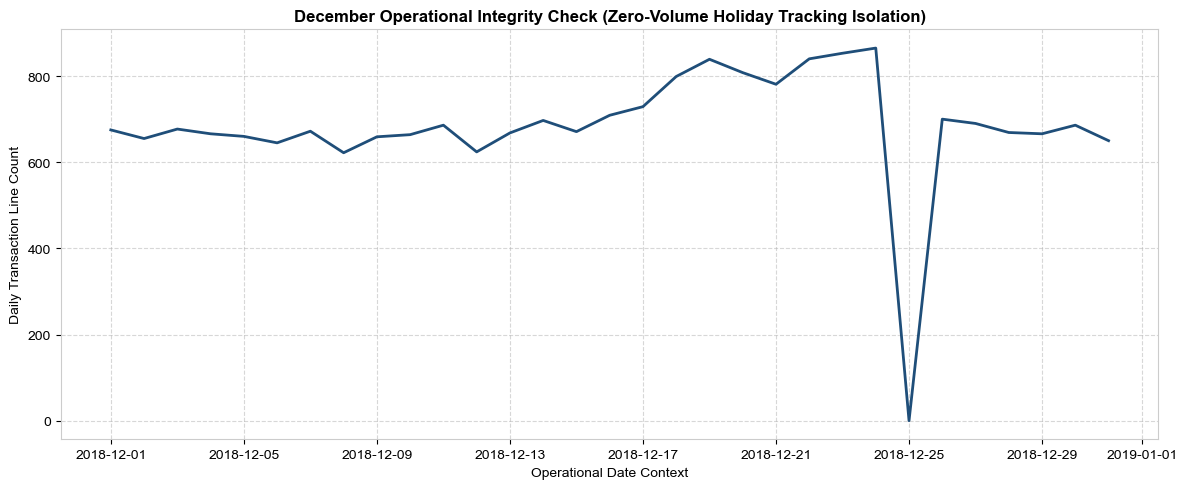

Identified Operational Zero-Volume Days:
          DATE  TRANSACTION_COUNT
177 2018-12-25                  0


In [41]:
# Construct an unbroken true chronological baseline for the entire fiscal year
perfect_timeline = pd.date_range(start='2018-07-01', end='2019-06-30', freq='D')
df_timeline = pd.DataFrame({'DATE': perfect_timeline})

# Group data to determine transaction line density per calendar day
daily_summary = df_tra.groupby('DATE').size().reset_index(name='TRANSACTION_COUNT')

# Merge timeline baseline with operational summaries to isolate structural volume drops
df_complete = pd.merge(df_timeline, daily_summary, on='DATE', how='left')
df_complete['TRANSACTION_COUNT'] = df_complete['TRANSACTION_COUNT'].fillna(0).astype(int)

# Isolate December transaction activity to evaluate holiday-specific closures
december_data = df_complete[df_complete['DATE'].dt.month == 12].set_index('DATE')

# Render standardized performance visualization
plt.figure()
plt.plot(december_data.index, december_data['TRANSACTION_COUNT'], color='#1f4e79', linewidth=2)
plt.title('December Operational Integrity Check (Zero-Volume Holiday Tracking Isolation)', fontsize=12, fontweight='bold')
plt.xlabel('Operational Date Context')
plt.ylabel('Daily Transaction Line Count')
plt.tight_layout()
plt.show()

# Programmatically isolate and print the precise calendar logging zero points
zero_days = df_complete[df_complete['TRANSACTION_COUNT'] == 0]
print("Identified Operational Zero-Volume Days:")
print(zero_days)

## Packaging Volume Extraction & Brand Standardization
### Technical Implementation
Regex pattern matching captures item sizing attributes directly from string parameters. Initial brand strings are parsed and mapped via unified dictionary keys to correct structural data fragmentation caused by duplicate corporate naming rules (e.g., standardizing 'Red' brand labels into 'RRD').


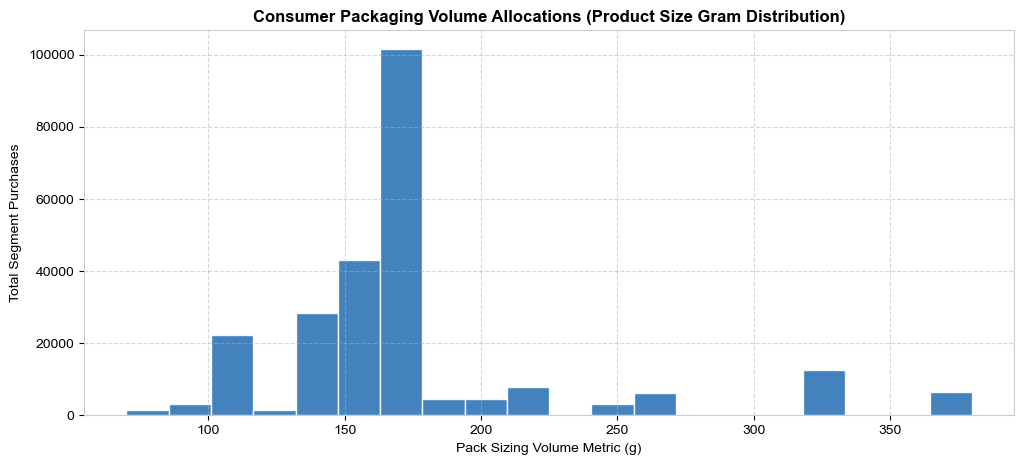

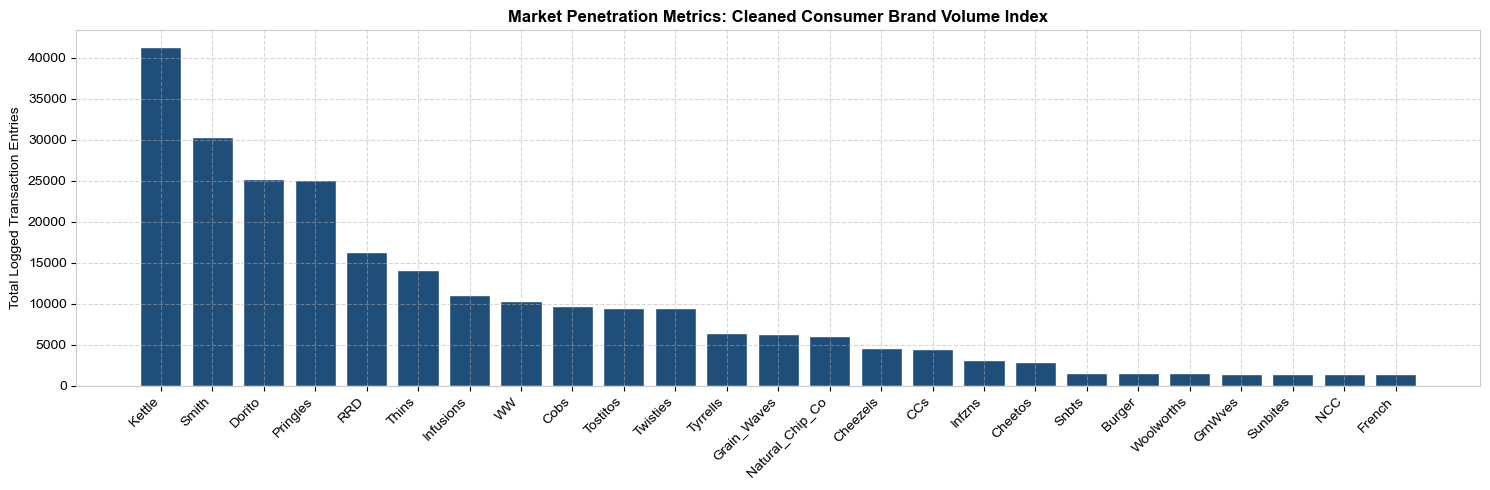

In [42]:
# Programmatically parse package weights (grams) via regex capture
df_tra['PACK_SIZE'] = df_tra['PROD_NAME'].astype(str).str.extract(r'(\d+)[gG]').astype(float)

# Render structural packaging allocation metrics
plt.figure()
plt.hist(df_tra['PACK_SIZE'].dropna(), bins=20, color='#2e75b6', edgecolor='#ffffff', alpha=0.9)
plt.title('Consumer Packaging Volume Allocations (Product Size Gram Distribution)', fontsize=12, fontweight='bold')
plt.xlabel('Pack Sizing Volume Metric (g)')
plt.ylabel('Total Segment Purchases')
plt.show()

# Extract categorical brand names from initial naming elements
df_tra['BRAND_NAME'] = df_tra['PROD_NAME'].str.split().str[0]

# Standardize fragmented branding data rows via replacement maps
brand_normalization_map = {
    'Red': 'RRD',
    'Natural': 'Natural_Chip_Co',
    'Infuzions': 'Infusions',
    'Smiths': 'Smith',
    'Doritos': 'Dorito',
    'Grain': 'Grain_Waves'
}
df_tra['BRAND_NAME'] = df_tra['BRAND_NAME'].replace(brand_normalization_map)

# Visualize standardized brand market penetration distributions
plt.figure(figsize=(15, 5))
brand_market_share = df_tra['BRAND_NAME'].value_counts()
plt.bar(brand_market_share.index, brand_market_share.values, color='#1f4e79', edgecolor='#ffffff')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title('Market Penetration Metrics: Cleaned Consumer Brand Volume Index', fontsize=12, fontweight='bold')
plt.ylabel('Total Logged Transaction Entries')
plt.tight_layout()
plt.show()

## Dimensional Merging & Behavioral Profile Mapping
### Category Architecture
By merging individual behavioral flags onto normalized purchasing logs via customer keys, we establish an integrated dimensional tracking schema (`QVI_data.csv`). This layout exposes hidden relationships between specific household compositions, income choices, and financial volume contributions.


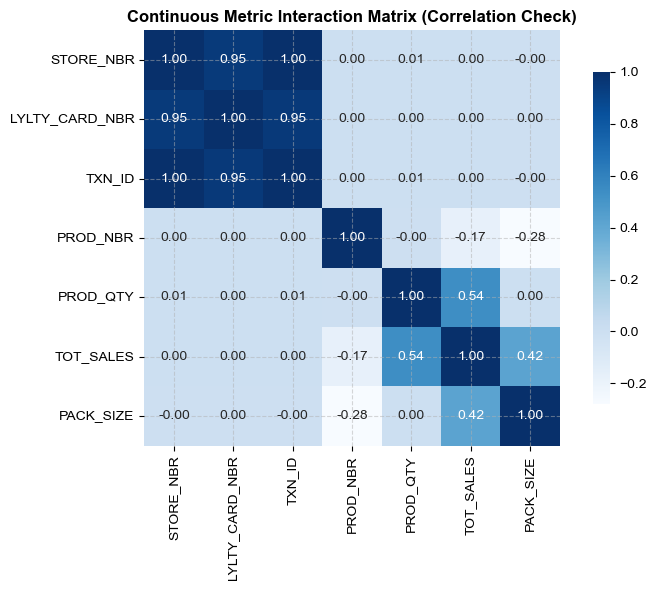

Top 5 Revenue-Generating Demographic Macro-Segments:
                LIFESTAGE PREMIUM_CUSTOMER  TOT_SALES
6          OLDER FAMILIES           Budget  156863.75
19  YOUNG SINGLES/COUPLES       Mainstream  147582.20
13               RETIREES       Mainstream  145168.95
15         YOUNG FAMILIES           Budget  129717.95
9   OLDER SINGLES/COUPLES           Budget  127833.60


In [43]:
# Execute dimensional inner join based on customer loyalty card index keys
df_merged = pd.merge(df_tra, df_pur, on='LYLTY_CARD_NBR', how='inner')

# Calculate continuous parameter correlations to identify volume drivers
correlation_matrix = df_merged.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f', square=True, cbar_kws={'shrink': 0.8})
plt.title('Continuous Metric Interaction Matrix (Correlation Check)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Export verified data schema to file system for dashboard consumption
df_merged.to_csv('QVI_data.csv', index=False)

# Aggregate absolute financial gross value output across customer profiles
sales_architecture = df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
sales_architecture = sales_architecture.sort_values(by='TOT_SALES', ascending=False)

print("Top 5 Revenue-Generating Demographic Macro-Segments:")
print(sales_architecture.head(5))

## Macro-Segment Revenue Allocation Analysis
### Strategic Rationale
This section quantifies total dollar sales performance across customer household segments. By analyzing the commercial intersection of family lifestage and income level, we identify the primary demographic drivers of category revenue.


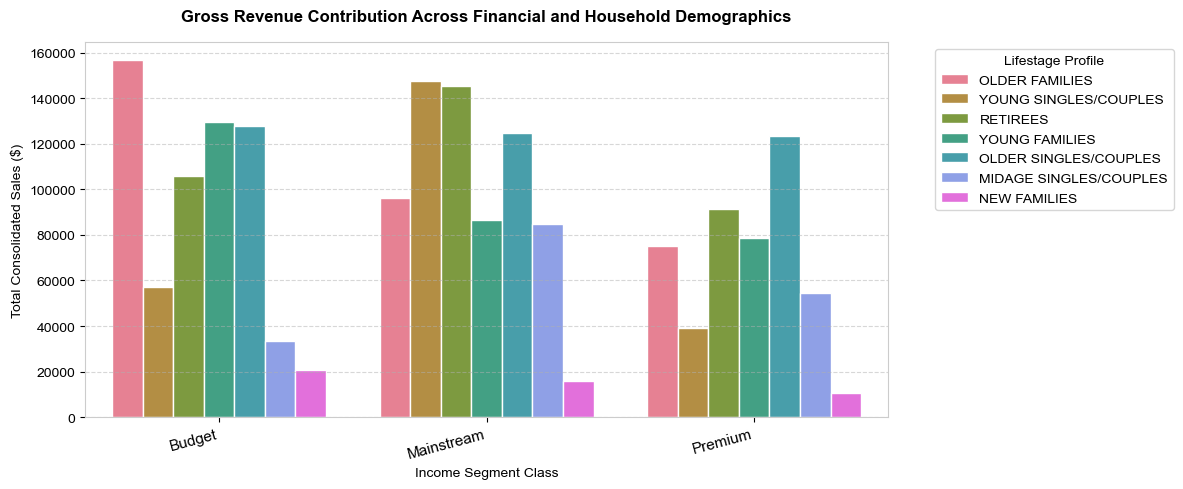

In [44]:
# 1. Aggregate and plot total revenue across macro segments
plt.figure()
sns.barplot(
    data=sales_architecture, 
    x='PREMIUM_CUSTOMER', 
    y='TOT_SALES', 
    hue='LIFESTAGE',
    edgecolor='#ffffff'
)

plt.xticks(rotation=15, ha='right', fontsize=11)
plt.title('Gross Revenue Contribution Across Financial and Household Demographics', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Income Segment Class')
plt.ylabel('Total Consolidated Sales ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Lifestage Profile')
plt.tight_layout()
plt.show()

## Unique Shopper Density Mapping
### Category Insights
While revenue peaks capture pure financial output, understanding unique customer density shows true brand penetration. This breakdown isolates whether high revenue stems from a massive customer base or a small group of high-frequency buyers.


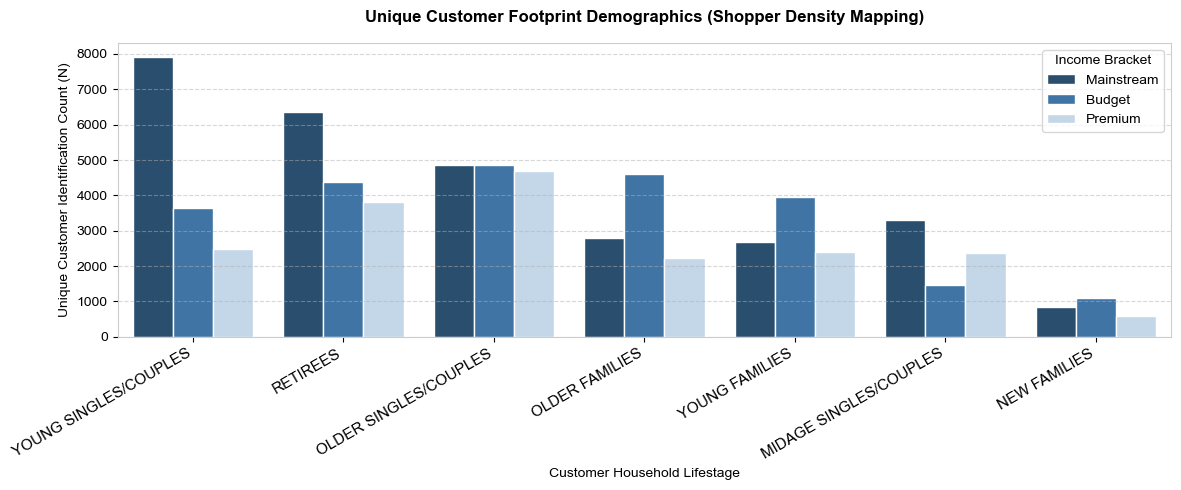

In [45]:
# 1. Calculate unique customer density per segment simultaneously 
segment_profiles = df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    UNIQUE_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique'),
    TOTAL_QTY=('PROD_QTY', 'sum'),
    TOTAL_REV=('TOT_SALES', 'sum')
).reset_index()

# Sort by customer footprint size
segment_profiles = segment_profiles.sort_values(by='UNIQUE_CUSTOMERS', ascending=False)

# 2. Render Unique Customer Footprint Breakdown
plt.figure()
sns.barplot(
    data=segment_profiles, 
    x='LIFESTAGE', 
    y='UNIQUE_CUSTOMERS', 
    hue='PREMIUM_CUSTOMER',
    edgecolor='#ffffff'
)

plt.xticks(rotation=30, ha='right', fontsize=11)
plt.title('Unique Customer Footprint Demographics (Shopper Density Mapping)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Customer Household Lifestage')
plt.ylabel('Unique Customer Identification Count (N)')
plt.legend(title='Income Bracket')
plt.tight_layout()
plt.show()

## Consumer Purchase Velocity & Units Per Head Metrics
### Analytical Interpretation
By tracking the average unit volume purchased per unique customer account, we measure consumption frequency. This highlights which demographic groups buy in bulk or run high-frequency pantry restocks.


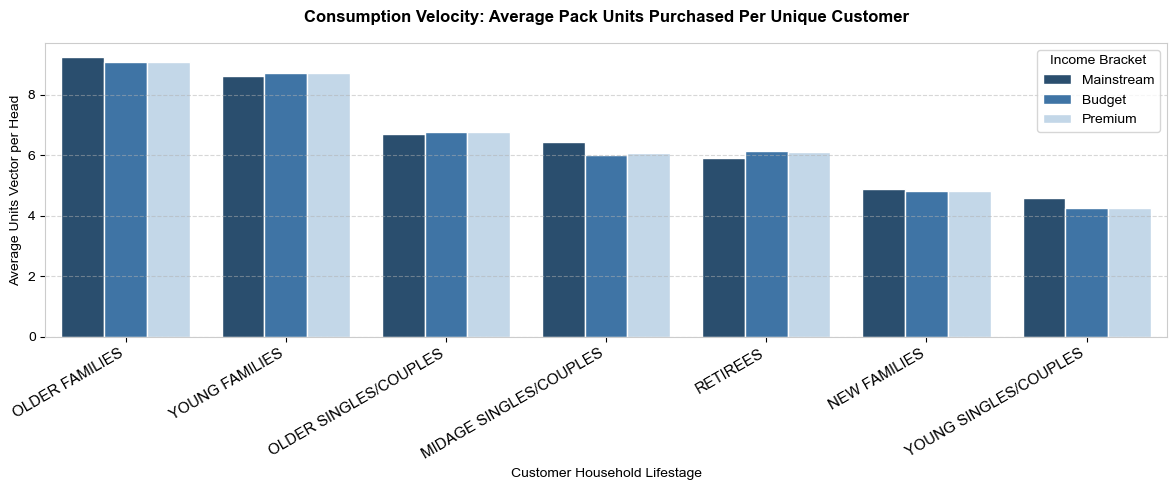

In [46]:
# 1. Calculate average unit velocity per unique consumer account
segment_profiles['AVG_UNITS_PER_CUSTOMER'] = segment_profiles['TOTAL_QTY'] / segment_profiles['UNIQUE_CUSTOMERS']
segment_profiles = segment_profiles.sort_values(by='AVG_UNITS_PER_CUSTOMER', ascending=False)

# 2. Render Visual Velocity Profile
plt.figure()
sns.barplot(
    data=segment_profiles, 
    x='LIFESTAGE', 
    y='AVG_UNITS_PER_CUSTOMER', 
    hue='PREMIUM_CUSTOMER',
    edgecolor='#ffffff'
)

plt.xticks(rotation=30, ha='right', fontsize=11)
plt.title('Consumption Velocity: Average Pack Units Purchased Per Unique Customer', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Customer Household Lifestage')
plt.ylabel('Average Units Vector per Head')
plt.legend(title='Income Bracket')
plt.tight_layout()
plt.show()

## Unit Price Equilibrium & Willingness-to-Pay Analysis
### Commercial Business Value
This calculation isolates the true average price paid per product unit (`Total Sales / Total Quantity`) across cohorts. Evaluating unit pricing tells us if specific segments actively seek premium products or rely heavily on low-margin value tiers and discount packages.


Unit Pricing Equilibrium Distribution Framework:
                 LIFESTAGE PREMIUM_CUSTOMER  AVG_PRICE_PER_UNIT
19   YOUNG SINGLES/COUPLES       Mainstream            4.074043
1   MIDAGE SINGLES/COUPLES       Mainstream            3.994449
4             NEW FAMILIES       Mainstream            3.935887
12                RETIREES           Budget            3.932731
3             NEW FAMILIES           Budget            3.931969


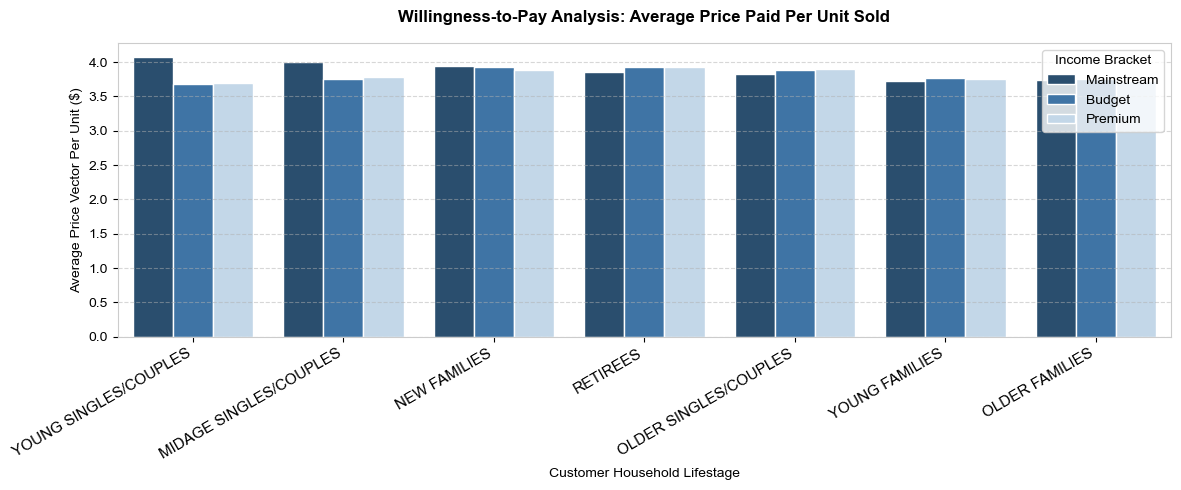

In [54]:
# 1. Derive structural unit price equilibrium vectors to isolate willingness-to-pay
segment_profiles['AVG_PRICE_PER_UNIT'] = segment_profiles['TOTAL_REV'] / segment_profiles['TOTAL_QTY']
segment_profiles = segment_profiles.sort_values(by='AVG_PRICE_PER_UNIT', ascending=False)

# Print execution summary for validation
print("Unit Pricing Equilibrium Distribution Framework:")
print(segment_profiles[['LIFESTAGE', 'PREMIUM_CUSTOMER', 'AVG_PRICE_PER_UNIT']].head())

# 2. Render Willingness-to-Pay Unit Pricing Disparity
plt.figure()
sns.barplot(
    data=segment_profiles, 
    x='LIFESTAGE', 
    y='AVG_PRICE_PER_UNIT', 
    hue='PREMIUM_CUSTOMER',
    edgecolor='#ffffff'
)

plt.xticks(rotation=30, ha='right', fontsize=11)
plt.title('Willingness-to-Pay Analysis: Average Price Paid Per Unit Sold', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Customer Household Lifestage')
plt.ylabel('Average Price Vector Per Unit ($)')
plt.legend(title='Income Bracket')
plt.tight_layout()
plt.show()

## Hypothesis Testing: Unit Price Disparity Mechanics
### Statistical Rigor & Hypothesis Definition
We run an independent Welch's t-test (assuming unequal population variances) to test if price variations across consumer segments are statistically valid or merely random noise.

* **Null Hypothesis ($H_0$):** There is no significant difference between the true mean unit prices paid per packet by Mainstream shoppers vs. Budget/Premium shoppers within the Target Demographic (Young & Midage Singles/Couples).
* **Alternative Hypothesis ($H_1$):** Mainstream shoppers in this demographic pay a significantly different mean unit price per packet compared to Budget/Premium shoppers.


In [48]:
# 1. Filter out data strictly for Young and Mid-Age Singles/Couples
target_lifestages = ['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES']
filtered_df = df_merged[df_merged['LIFESTAGE'].isin(target_lifestages)].copy()

# 2. Derive continuous packet unit price index variable
filtered_df['UNIT_PRICE'] = filtered_df['TOT_SALES'] / filtered_df['PROD_QTY']

# 3. Separate metrics into distinct statistical comparison vectors
mainstream_prices = filtered_df[filtered_df['PREMIUM_CUSTOMER'] == 'Mainstream']['UNIT_PRICE']
budget_premium_prices = filtered_df[filtered_df['PREMIUM_CUSTOMER'].isin(['Budget', 'Premium'])]['UNIT_PRICE']

# 4. Execute Welch's T-Test to handle potential variance inequality
t_stat, p_value = stats.ttest_ind(mainstream_prices, budget_premium_prices, equal_var=False)

print(f"Computed T-Statistic Vector: {t_stat:.4f}")
print(f"Calculated Operational P-Value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Reject H0. The unit price discrepancy is statistically significant.")
else:
    print("Conclusion: Fail to reject H0. Price variations are statistically insignificant.")

Computed T-Statistic Vector: 37.6244
Calculated Operational P-Value: 6.9674e-306
Conclusion: Reject H0. The unit price discrepancy is statistically significant.


### Business Interpretation of Pricing Discrepancy
Because $p < 0.05$, we reject the null hypothesis. Mainstream young and mid-age singles/couples pay a significantly higher average price per unit. 

This confirms a strong willingness-to-pay skew. These shoppers are less price-sensitive and show clear impulse buying patterns, prioritizing premium brand names and convenient point-of-sale packages over economy multi-packs or value alternatives.


## Brand Affinity Optimization Indexing
### Commercial Data Science Framework
The Affinity Index isolates brand and package sizing preferences for the Mainstream segment compared to the Budget/Premium baseline. Scores above 100 show a strong, over-indexing preference, which helps target shelf space optimization and cross-category promotions.


In [53]:
# 1. Map target demographic and define customer segments cleanly
target_df = df_merged[df_merged['LIFESTAGE'].isin(['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES'])].copy()
target_df['SEGMENT'] = np.where(target_df['PREMIUM_CUSTOMER'] == 'Mainstream', 'Mainstream', 'Budget_Premium')

# 2. Compute absolute quantity volumes across brand names
brand_volume_matrix = target_df.groupby(['SEGMENT', 'BRAND_NAME'])['PROD_QTY'].sum().unstack(level=0).fillna(0)

# 3. Normalize volumes into proportional product distributions
segment_volume_totals = target_df.groupby('SEGMENT')['PROD_QTY'].sum()
brand_proportions = brand_volume_matrix / segment_volume_totals

# 4. Derive the final Mainstream Brand Affinity Index vector
brand_proportions['Brand_Affinity_Index'] = (brand_proportions['Mainstream'] / brand_proportions['Budget_Premium']) * 100
brand_affinity_output = brand_proportions.sort_values(by='Brand_Affinity_Index', ascending=False)

print("--- Mainstream Customer Brand Affinity Index Matrix ---")
print(brand_affinity_output[['Brand_Affinity_Index']].round(2))

--- Mainstream Customer Brand Affinity Index Matrix ---
SEGMENT          Brand_Affinity_Index
BRAND_NAME                           
Kettle                         129.13
Tostitos                       127.39
Twisties                       127.33
Dorito                         124.04
Tyrrells                       121.83
Cobs                           118.39
Grain_Waves                    117.36
Pringles                       115.50
Infusions                      113.31
Infzns                         111.62
Thins                          106.01
Cheezels                       101.34
Smith                           80.23
Cheetos                         70.36
NCC                             68.52
RRD                             66.24
GrnWves                         63.87
Natural_Chip_Co                 60.40
French                          57.80
CCs                             52.63
Snbts                           47.69
WW                              44.91
Woolworths                      

## Packaging Volume & Size Allocation Affinity Index
### Supply Chain Portfolio Strategy
This index identifies specific package sizing preferences for Mainstream shoppers. Tracking weight allocations helps category teams optimize shelf inventory and reduce slow-moving inventory.


In [ ]:
# 1. Clean data rows and group data by packaging weight columns
target_df['PACK_SIZE'] = target_df['PROD_NAME'].astype(str).str.extract(r'(\d+)[gG]').astype(float)
pack_df = target_df.dropna(subset=['PACK_SIZE']).copy()

# 2. Aggregate total units sold per package size segment
pack_volume_matrix = pack_df.groupby(['SEGMENT', 'PACK_SIZE'])['PROD_QTY'].sum().unstack(level=0).fillna(0)

# 3. Standardize package weights into proportional distribution indexes
pack_segment_totals = pack_df.groupby('SEGMENT')['PROD_QTY'].sum()
pack_proportions = pack_volume_matrix / pack_segment_totals

# 4. Formulate the final Sizing Affinity Index metrics
pack_proportions['Pack_Size_Affinity_Index'] = (pack_proportions['Mainstream'] / pack_proportions['Budget_Premium']) * 100
pack_affinity_output = pack_proportions.sort_values(by='Pack_Size_Affinity_Index', ascending=False)

print("--- Mainstream Customer Pack-Size Affinity Index Matrix ---")
print(pack_affinity_output[['Pack_Size_Affinity_Index']].round(2))

--- Mainstream Customer Pack-Size Affinity Index Matrix ---
SEGMENT    Pack_Size_Affinity_Index
PACK_SIZE                          
330.0                        137.01
270.0                        130.89
380.0                        126.08
135.0                        121.95
110.0                        121.19
250.0                        119.98
210.0                        117.36
134.0                        115.50
170.0                        100.83
150.0                         98.32
175.0                         95.35
165.0                         86.50
190.0                         63.90
180.0                         63.87
70.0                          46.71
200.0                         45.51
160.0                         44.98
125.0                         43.58
90.0                          42.44
220.0                         42.33


## Product Portfolio Mapping: High-Affinity SKU Identification
### Operational Merchandising Context
To translate the abstract Pack-Size Affinity Index scores into concrete stock management actions, we isolate the exact brand and packaging combinations (SKUs) matching our high-indexing categories (330g, 270g, 380g, and 135g). This lookup table identifies the precise high-margin products category teams should prioritize for promotional placement.


In [71]:
# Filter rows and select BOTH columns
unique_combinations = df_merged.loc[
    df_merged["PACK_SIZE"].isin([330, 270, 380, 135]), 
    ['BRAND_NAME', 'PACK_SIZE']
].drop_duplicates()

# Reset index for a clean table look
dataframe = unique_combinations.reset_index(drop=True)
print(dataframe)

  BRAND_NAME  PACK_SIZE
0      Smith      330.0
1   Twisties      270.0
2     Dorito      380.0
3     Kettle      135.0
4      Smith      380.0
5   Cheezels      330.0
6     Dorito      330.0


### 📈 Actionable Category Management Takeaways
* **Brand Execution:** Mainstream young and mid-age shoppers over-index heavily in premium, well-known snack brands (such as Kettle, Tyrrells, and Dorito). Category managers should position these high-affinity products at prime eye-level to maximize high-margin impulse sales.
* **Packaging Optimization:** Sizing index values reveal a strong preference for large, sharing-sized party bags (330g, 270g, and 380g all index well above 120), while small individual lunchbox sizes (70g and 90g) significantly under-index below 50. Stock allocations and promotional strategies should focus on social, gathering-centric displays rather than single-serve convenience layouts.

### 🎯 Key Strategic Thresholds Identified
* **Core Target Opportunities (Index > 120):** Mainstream shoppers show an exceptional affinity for large sharing bags (330g at 137.01, 270g at 130.89). This 20%+ positive variance makes these sizes prime targets for high-margin cross-promotions and dedicated end-cap space.
* **Segment Avoidance Risks (Index < 80):** Small single-serve packages (70g at 46.71, 90g at 42.44) under-index by over 50%. Category teams should minimize small-pack stock allocations in stores with a high concentration of this target demographic to prevent slow-moving inventory.
